In this notebook, we compute the local lens-space density of the UN general debate corpus. 

In [1]:
import pandas as pd
import numpy as np

ungdc_df = pd.read_parquet("https://huggingface.co/datasets/kalebr/un-general-debate-corpus-chunked/resolve/main/ungdc-all-chunked.parquet")
ungdc_df.head(1)

,original_index,chunk_text,token_count,embedding,reduced,session,year,country,information_weight
0,0,﻿It is indeed a pleasure for me and the member...,107,"[0.0061351038, 0.020647585, 0.01789057, 0.0222...","[6.317007541656494, 7.351022243499756]",44,1989,MDV,39.726044


In [ ]:
"""
Parameters

"""
data_path = "./output_data/UN-Density"

## If you aren't using Anthropic, you will need to modify the next cell as well.
api_key_file = 'cohere.txt' # below assumed to be Cohere

## Quantile of data to drop (sorted by information weight) 
q = 50

## Mapper settings
number_of_slices = 10 # approximately 50 years of data ~5 years/slice
k_neighbours = 500


## Toponymy settings
model_name = 'all-MiniLM-L6-v2' # embedding model.

toponymy_object_description = "excerpts from a speech"
toponymy_corpus_description = "United Nations General Debate Transcripts"

toponymy_exemplar_method = "central"
toponymy_keyphrase_method = "information_weighted"
toponymy_subtopic_method = "facility_location"

### THE CLUSTERER PARAMS DOMINATE RUNTIME -- MORE CLUSTERS IS EXPONENTIALLY SLOWER ###
clusterer_params = {
    'min_clusters':4,
    'base_min_cluster_size':100,
    'verbose':True
}



In [ ]:
## Toponymy LLM Wrapper Setup
from toponymy.llm_wrappers import AzureAINamer

with open(api_key_file, 'r') as file:
    api_key = file.read().strip()
# Initialize Cohere wrapper  
llm=AzureAINamer(
    api_key, 
    endpoint="https://azureaitimcuse5821437469.services.ai.azure.com/models",
    model="Cohere-command-r-08-2024",
)
# Test connection  
llm.test_llm_connectivity()  

  Failed to connect to AnthropicNamer using claude-3-haiku-20240307
  Cause:  BadRequestError: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'You have reached your specified API usage limits. You will regain access on 2026-04-01 at 00:00 UTC.'}, 'request_id': 'req_011CZ3eYTLWFyQwgQ9chb3Mc'}


'<error>'

In [4]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
from tqdm.auto import tqdm

# Register tqdm with pandas
tqdm.pandas()

# Create `data_path` if it doesn't exist.
Path(data_path).mkdir(parents=True, exist_ok=True) 

cutoff = np.percentile(ungdc_df['information_weight'].values, q)
df = ungdc_df[ungdc_df['information_weight']>=cutoff]

embedding_vectors = np.stack(df['embedding'].values)
reduced_vectors = np.stack(df['reduced'].values)
time = df['year'].to_numpy()
text = df['chunk_text'].to_numpy()

# Sort all arrays by time
sorted_idx = np.argsort(time)
time = time[sorted_idx]
text = text[sorted_idx]
reduced_vectors = np.vstack(reduced_vectors[sorted_idx])
embedding_vectors = np.vstack(embedding_vectors[sorted_idx])
df.head(1)

,original_index,chunk_text,token_count,embedding,reduced,session,year,country,information_weight
0,0,﻿It is indeed a pleasure for me and the member...,107,"[0.0061351038, 0.020647585, 0.01789057, 0.0222...","[6.317007541656494, 7.351022243499756]",44,1989,MDV,39.726044


In [5]:

from toponymy import Toponymy, ToponymyClusterer

from sentence_transformers import SentenceTransformer
import torch
# Check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load the embedding model
# Options: 'all-MiniLM-L6-v2' (fast, 384 dim), 'all-mpnet-base-v2' (better quality, 768 dim)
model = SentenceTransformer(model_name, device=device)
print(f"Loaded model: {model_name}")


## Cluster and check that we're happy with the # of clusters
clusterer = ToponymyClusterer(**clusterer_params)
clusterer.fit(reduced_vectors, embedding_vectors)

Using device: cpu


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded model: all-MiniLM-L6-v2
Layer 0 found 66 clusters
Layer 1 found 17 clusters
Layer 2 found 4 clusters


In [ ]:
## Compute a toponymy of the entire dataset.
from toponymy.serialization import TopicModel

toponymy_params = {
    'llm_wrapper':llm,
    'text_embedding_model':model,
    'clusterer':clusterer,
    'object_description':"excerpts from a speech",
    'corpus_description':"United Nations General Debate Transcripts",
    'exemplar_delimiters':["<EXAMPLE_TRANSCRIPT>\n","\n</EXAMPLE_TRANSCRIPT>\n\n"],
}
toponymy_fit_params = {
    'exemplar_method':toponymy_exemplar_method,
    'keyphrase_method':toponymy_keyphrase_method,
    'subtopic_method':toponymy_subtopic_method,
}


toponymy = Toponymy(**toponymy_params)
toponymy.fit(text, embedding_vectors, reduced_vectors, **toponymy_fit_params)

# Save to disk:
topicmodel = TopicModel.from_toponymy(toponymy, document_df=df)
topicmodel.to_file("ungdc-topic-model.tm.zip")

In [38]:
from temporalmapper import TemporalMapper
from temporalmapper.kernels import square

TM = TemporalMapper(
    time,
    reduced_vectors,
    None,
    N_checkpoints = 8,
    neighbours = 5000,
    kernel=square
)
try:
    TM.build()
except TypeError:
    # Becaue the clusterer=None when we initialized the TemporalMapper
    # build() will throw a TypeError. This doesn't matter for the
    # density calculation:
    print(TM.density)

[0.96829729 0.80007829 0.78913042 ... 0.98660353 0.91937231 0.93532886]


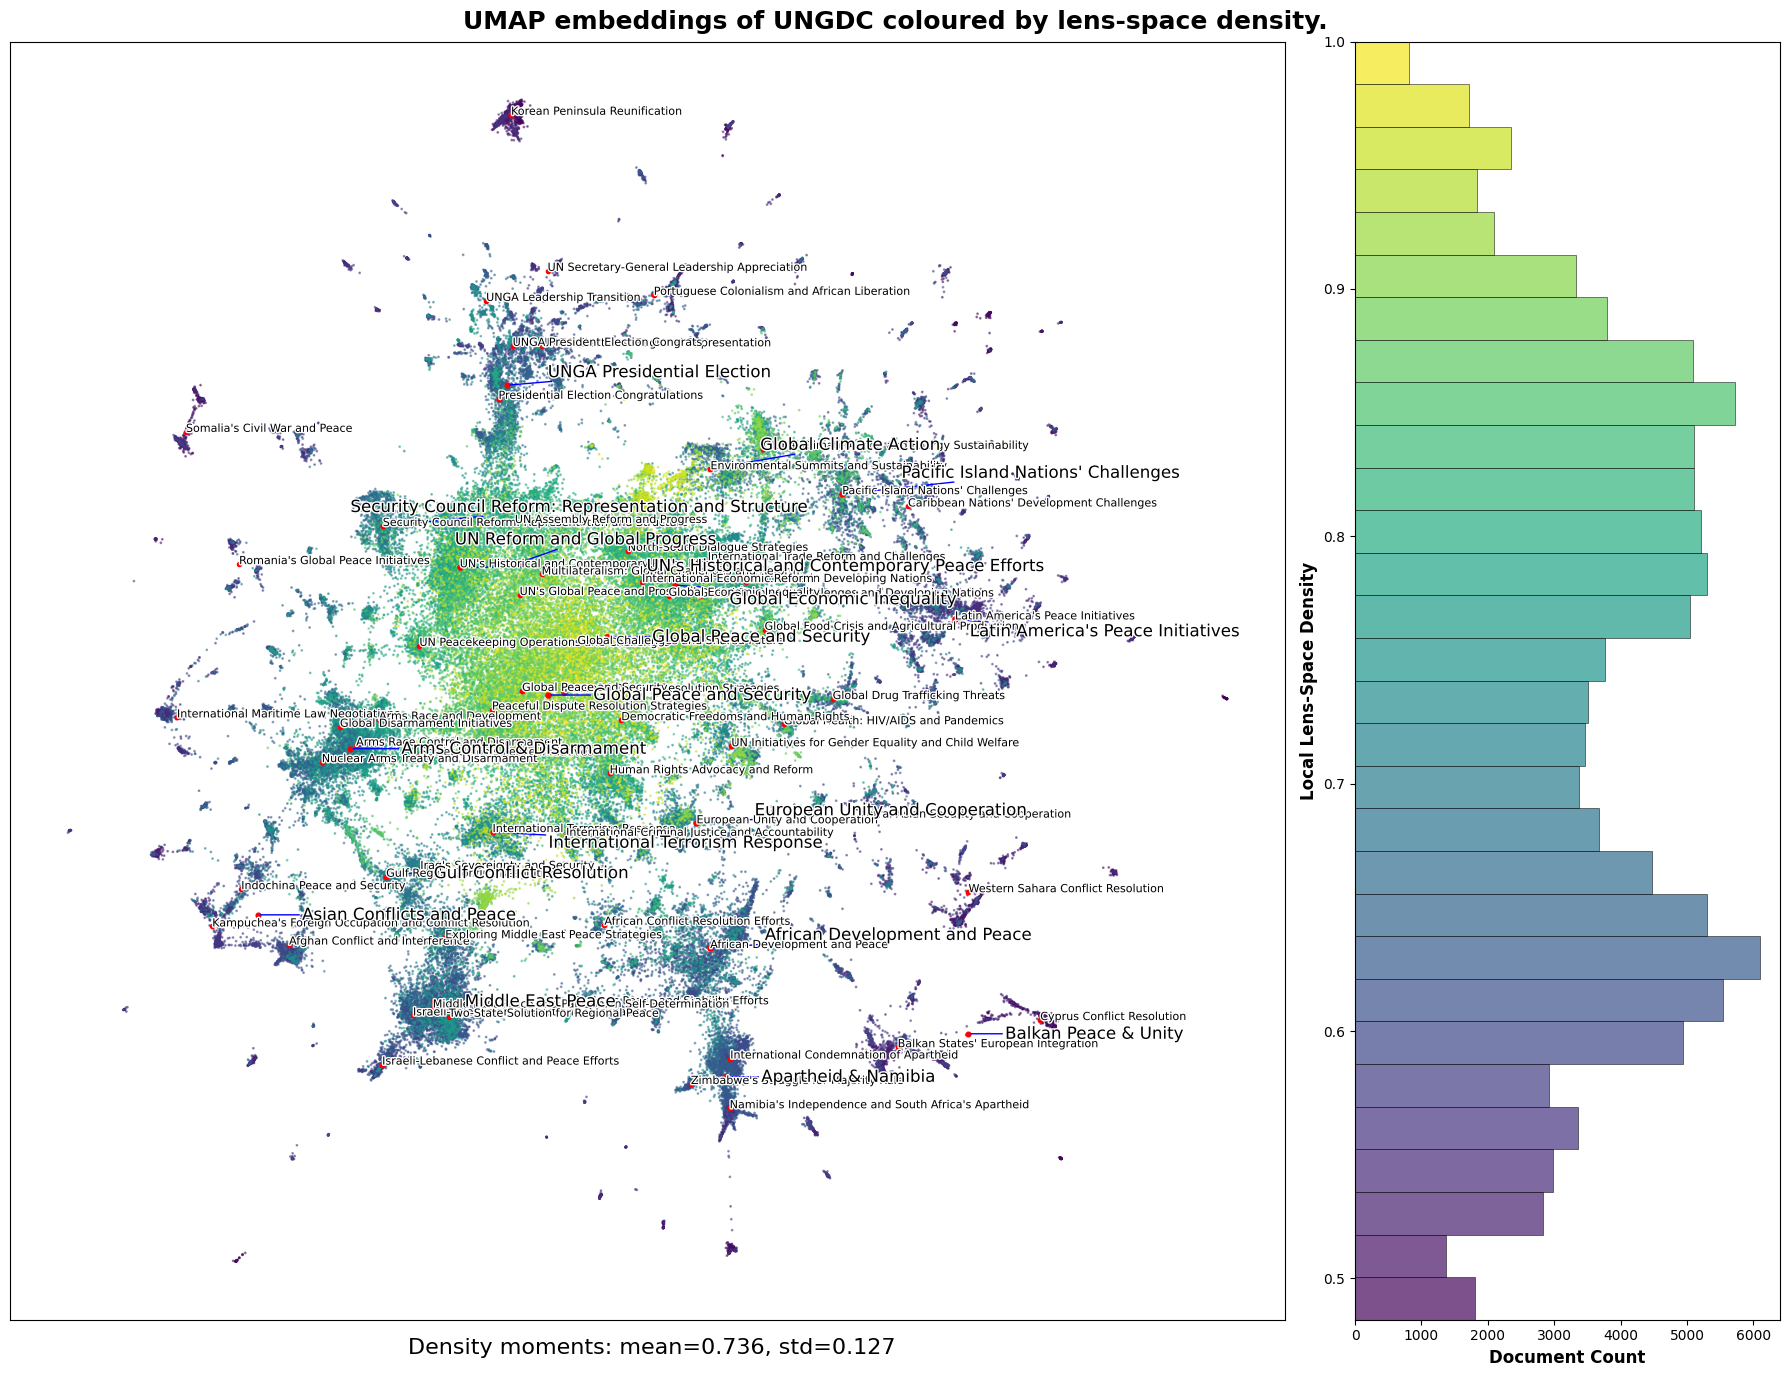

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
import matplotlib.patheffects

def plot_cluster_labels(toponymy, axis):
    for layer in {1,2}:
        if layer == 2:
            size = 12
        if layer == 1:
            size = 8
        cluster_labels = toponymy.cluster_layers_[layer].cluster_labels  
        clusters = np.unique(cluster_labels)
        texts = []
        for c in clusters:
            name = toponymy.cluster_layers_[layer].topic_names[c]
            cluster_vectors = reduced_vectors[cluster_labels == c]
            n_documents = cluster_vectors.shape[0]
            centroid = np.mean(cluster_vectors, axis=0)
            texts.append(
                axis.text(centroid[0], centroid[1], name,
                          color='black', fontsize=size,
                          path_effects=[matplotlib.patheffects.Stroke(linewidth=2, foreground='white'), matplotlib.patheffects.Normal()]
                         )
            )
            axis.scatter(centroid[0], centroid[1], s=np.log2(n_documents), c='red')
    texts, patches = adjust_text(texts, arrowprops=dict(arrowstyle="-", color='blue'), ax=axis, min_arrow_len=0, time_lim=1)
    return axis


fig, axes = plt.subplots(1, 2, figsize=(18, 14), gridspec_kw={'width_ratios': [3, 1]})

density = TM.density
# Scatterplot with density coloring
sc = axes[0].scatter(
    reduced_vectors[:, 0],
    reduced_vectors[:, 1],
    c=density,
    s=1,
    alpha=0.5,
    cmap='viridis'
)

# # Crop out some outliers to zoom in more on the main data.
# x_min, x_max = np.percentile(reduced_vectors[:, 0], [1, 99])
# y_min, y_max = np.percentile(reduced_vectors[:, 1], [1, 99])
# # Reuse x-lims to keep the axes on the same scale.
# axes[0].set_xlim(x_min*1.3, x_max*1.3)
# axes[0].set_ylim(x_min*1.3, x_max*1.3)

# UMAP scale is meaningless so remove ticks
axes[0].set_xticks([])
axes[0].set_yticks([])

# Plot histogram of density values with aligned axis
counts, bins, patches = axes[1].hist(
    density, 
    bins=30, 
    orientation='horizontal', 
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

# Color the histogram bins to match the colormap
norm = plt.Normalize(vmin=density.min(), vmax=density.max())
cmap = plt.cm.viridis

for i, patch in enumerate(patches):
    bin_center = (bins[i] + bins[i + 1]) / 2
    color = cmap(norm(bin_center))
    patch.set_facecolor(color)

#axes[1].set_title('Density Histogram', fontsize='14', fontweight='bold')
axes[1].set_xlabel('Document Count', fontsize='12', fontweight='bold')
axes[1].set_ylabel('Local Lens-Space Density', fontsize='12', fontweight='bold')

# Align the y-axes
axes[1].set_ylim(np.amax(density), np.amin(density))
axes[1].invert_yaxis()

plot_cluster_labels(toponymy, axes[0])


# some summary statistics
mu = np.mean(density)
sigma = np.std(density)
plt.figtext(0.5, 0.02, f'Density moments: mean={mu:.3f}, std={sigma:.3f}', ha='right', c='black', fontsize=16)

fig.suptitle('UMAP embeddings of UNGDC coloured by lens-space density.', fontsize=18, fontweight='bold')
#plt.figtext(0.9, 1, 'UNCLASSIFIED//OUO', ha='right', c='green', fontsize=14, bbox={"facecolor":"white", "alpha":0.5, "pad":5})
plt.tight_layout()
plt.savefig(data_path+"/density-visualization.png")
plt.show()